# Embeddings Multimodales 🎨
## El lenguaje universal

Los LLMs entienden el arte? El secreto es llevar el texto e imágenes al **mismo espacio vectorial**.

No hacen falta etiquetas. No hace falta entrenamiento extra. Solo geometría ☝🏽🤓

---
## 0. Setup

In [ ]:
import requests
import numpy as np
import pandas as pd
from pathlib import Path

from io import BytesIO
import plotly.graph_objects as go
from PIL import Image as PILImage
from IPython.display import display

from helpers.embeddings import get_client

from helpers.multimodal import (
    embed_image_url,
    embed_images_batch,
    embed_text_queries,
    cosine_similarity_matrix,
)

from helpers.met_data import (
    show_gallery,
    look_paintings_by_property
)

In [ ]:
CACHE_CSV = Path("local/assets/sample_csv/met.csv")
CACHE_EMB = Path("local/embeddings/met.npy")

CACHE_EMB.parent.mkdir(parents=True, exist_ok=True)

### 1. Checkpoint — Cargar CSV (si ya se corrió antes)

In [ ]:
df = pd.read_csv(CACHE_CSV)
print(f"✅ Dataset cargado: {len(df)} obras")
df.head()

✅ Dataset cargado: 110 obras


,artist,title,style,year,tags,image_url
0,Paul Cézanne,Mont Sainte-Victoire and the Viaduct of the Ar...,Impressionism,1882–85,"Bridges, Mountains, Landscapes",https://images.metmuseum.org/CRDImages/ep/web-...
1,Henry Lerolle,The Organ Rehearsal,Impressionism,1885,"Men, Women, Musicians, Singers",https://images.metmuseum.org/CRDImages/ep/web-...
2,Auguste Renoir,By the Seashore,Impressionism,1883,"Portraits, Women",https://images.metmuseum.org/CRDImages/ep/web-...
3,Pierre Puvis de Chavannes,The Shepherd's Song,Impressionism,1891,"Men, Women, Sheep, Shepherds",https://images.metmuseum.org/CRDImages/ep/web-...
4,Auguste Renoir,Still Life with Flowers and Prickly Pears,Impressionism,ca. 1885,"Pears, Flowers, Still Life, Vases",https://images.metmuseum.org/CRDImages/ep/web-...


---
## 2. Veamos el arte 👀

In [14]:
show_gallery(df, n=9)

---
## 3. Cómo que multimodal?

### El modelo: `gemini-embedding-2-preview`
```
Texto  ─┐
Imagen ─┤──► [embedding-2] ──► vector(3072)  ← mismo espacio
Audio  ─┤
Video  ─┘
```

Si texto e imagen están en el **mismo espacio**, podemos medir su distancia directamente:

| Comparación | Score esperado |
|-------------|----------------|
| `"campo de amapolas"` vs Monet | alto ✅ |
| `"pesadilla surrealista"` vs Monet | bajo ❌ |
| `"pesadilla surrealista"` vs Dalí | alto ✅ |

**Sin etiquetas. Sin entrenamiento extra. Solo el espacio vectorial compartido.**

---
## 4. Imagen --> Embedding

Obra:    Mont Sainte-Victoire and the Viaduct of the Arc River Valley
Artista: Paul Cézanne
Estilo:  Impressionism  (1882–85)


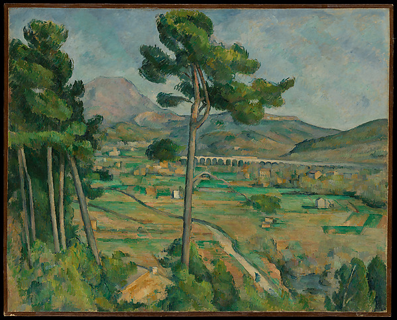

In [ ]:
# Tomamos una obra de Impresionismo
demo_row = df[df["style"].str.contains("Impress", na=False)].iloc[0]

print(f"Obra:    {demo_row['title']}")
print(f"Artista: {demo_row['artist']}")
print(f"Estilo:  {demo_row['style']}  ({demo_row['year']})")

resp = requests.get(demo_row["image_url"], headers={"User-Agent": "Mozilla/5.0"}, timeout=10)
img = PILImage.open(BytesIO(resp.content))
img.thumbnail((450, 320))
display(img)

Activamos nuestra conexión con Google

para usar cualquier modelo a través de una API (secreta)

In [16]:
client = get_client()

In [17]:
vec_imagen = embed_image_url(demo_row["image_url"], client=client)

print("💡 Esta pintura es ahora un punto en un espacio de 3072 dimensiones.")
print(f"Shape:           {vec_imagen.shape}")
print(f"Dtype:           {vec_imagen.dtype}")
print(f"Primeros 8:      {vec_imagen[:8].round(4)}")

💡 Esta pintura es ahora un punto en un espacio de 3072 dimensiones.
Shape:           (3072,)
Dtype:           float32
Primeros 8:      [ 0.0024 -0.028  -0.0335  0.0099  0.002  -0.0157 -0.0033 -0.0016]


---
## 5. Cross-Modal: Imagen vs Texto

Entre varias descripciones. ¿Cuál está más **CERCA** de esta pintura en el espacio vectorial?

In [ ]:
candidatos_texto = [
    "a serene and peaceful landscape, gentle sunlight filtering through trees, soft pastoral colors",
    "shining steel medieval armor, knights clashing in fierce battle, historical warfare",
    "divine mythological figures, epic celestial scenes, ancient gods and mythical creatures",
    "elegant portraits, high society luxury, extravagant dresses, opulent gold jewelry",
    "joyful people dancing, playing musical instruments, lively celebration and movement"
]

# Una sola llamada al API para todos los textos
vecs_texto = embed_text_queries(candidatos_texto, client=client, verbose=False)

v_img = vec_imagen / np.linalg.norm(vec_imagen)

print(f"Imagen: '{demo_row['title']}' — {demo_row['style']}")
print("─" * 60)
for texto, v_t in zip(candidatos_texto, vecs_texto):
    v_t_norm = v_t / np.linalg.norm(v_t)
    sim = float(v_img @ v_t_norm)
    barra = "█" * int(sim * 50)
    label = texto[:42] + "..."
    print(f"{sim:.4f}  {barra}")
    print(f"        '{label}'")

Imagen: 'Mont Sainte-Victoire and the Viaduct of the Arc River Valley' — Impressionism
────────────────────────────────────────────────────────────
0.3596  █████████████████
        'a serene and peaceful landscape, gentle su...'
0.2203  ███████████
        'shining steel medieval armor, knights clas...'
0.2771  █████████████
        'divine mythological figures, epic celestia...'
0.2751  █████████████
        'elegant portraits, high society luxury, ex...'
0.2268  ███████████
        'joyful people dancing, playing musical ins...'


---
## 6. Embeddings para Todas las Obras

Este paso llama a la API una vez por imagen (cuidado con la cantidad de imágenes, puede ser caro 💸).  

Los resultados se guardan en formato `.npy` como checkpoint.

In [24]:
image_embeddings = embed_images_batch(
    urls=df["image_url"].tolist(),
    cache_path=CACHE_EMB,
    client=client,
    verbose=True,
    delay=2.0,
)

print(f"\nShape: {image_embeddings.shape}")
print(f"  → {image_embeddings.shape[0]} imágenes × {image_embeddings.shape[1]} dims")

  ✅ 110 embeddings generados (3072 dims c/u)    
  Embeddings guardados en: local\embeddings\met.npy  ((110, 3072))

Shape: (110, 3072)
  → 110 imágenes × 3072 dims


---
## 7. Preguntas "Semánticas" 🫴🏽🍷

Eres dueñx de una galería y quieres encontrar las pinturas que van a gustarle a tus clientes.

Así que quieres agregar nuevas columnas a tu BD para evaluar qué tan darks es una pintura, o si hay animales o si transmite paz, etc, etc.

> **Importante:** Estas "queries" se embeddean con el **mismo modelo** (`gemini-embedding-2-preview`),
> lo que garantiza que las preguntas y las imágenes estén en el mismo espacio vectorial. Son comparables.

In [25]:
PREGUNTAS = [
    {
        "label":   "⚔️ combate",
        "display": "¿Muestra una batalla o guerreros con armadura?",
        "query":   "medieval armor knights battle fighting swords warfare steel weapons combat",
    },
    {
        "label":   "💎 opulencia",
        "display": "¿Muestra joyería extravagante o moda elegante?",
        "query":   "extravagant royal dresses opulent gold jewelry elegant velvet high society luxury fashion",
    },
    {
        "label":   "🐾 animales",
        "display": "¿Aparecen animales de compañía como perros o gatos?",
        "query":   "cats dogs animals domestic pets wildlife mammals creatures resting playing",
    },
    {
        "label":   "🎵 fiesta y baile",
        "display": "¿Muestra gente bailando o tocando música?",
        "query":   "joyful people dancing playing musical instruments lively celebration movement music musicians",
    },
    {
        "label":   "😌 naturaleza",
        "display": "¿Es un paisaje tranquilo al aire libre?",
        "query":   "peaceful calm serene nature light soft colors tranquil landscape trees outdoors scenery",
    },
    {
        "label":   "⛪ mística y sagrada",
        "display": "¿Parece una escena mitológica, mágica o religiosa?",
        "query":   "religious mythological gods angels sacred divine biblical classical magic spells witchcraft",
    },
]

for p in PREGUNTAS:
    print(f"  {p['label']:18s}  ←  {p['display']}")

  ⚔️ combate          ←  ¿Muestra una batalla o guerreros con armadura?
  💎 opulencia         ←  ¿Muestra joyería extravagante o moda elegante?
  🐾 animales          ←  ¿Aparecen animales de compañía como perros o gatos?
  🎵 fiesta y baile    ←  ¿Muestra gente bailando o tocando música?
  😌 naturaleza        ←  ¿Es un paisaje tranquilo al aire libre?
  ⛪ mística y sagrada  ←  ¿Parece una escena mitológica, mágica o religiosa?


In [26]:
# Una sola llamada al API — texto es muy barato
query_vecs = embed_text_queries(
    [p["query"] for p in PREGUNTAS],
    client=client,
)
print(f"Shape queries: {query_vecs.shape}")
print("\n✅ imágenes y preguntas están ahora en el mismo espacio vectorial")

  Generando 6 embeddings de texto...
  ✅ 6 embeddings de queries listos
Shape queries: (6, 3072)

✅ imágenes y preguntas están ahora en el mismo espacio vectorial


---
## 8. Cosine Similarity

`scores[i, j]` = similitud coseno entre la pregunta `i` y la imagen `j`.

> 💡 **Nota sobre el rango de valores:**
> Matemáticamente, la similitud coseno va de `[-1, 1]`, donde **1** es idéntico, **0** es ortogonal (sin relación) y **-1** es exactamente opuesto. 
> Sin embargo, debido a la arquitectura matemática de los modelos de embeddings actuales (como Gemini o CLIP), todos los vectores se agrupan en una región positiva del espacio. Por lo tanto, **en la práctica tus valores siempre caerán en el rango `[0, 1]`**.

In [27]:
scores = cosine_similarity_matrix(query_vecs, image_embeddings)
print(f"scores.shape = {scores.shape}  → {scores.shape[0]} preguntas × {scores.shape[1]} imágenes")
print(f"Rango: [{scores.min():.4f}, {scores.max():.4f}]")

scores.shape = (6, 110)  → 6 preguntas × 110 imágenes
Rango: [0.1082, 0.3857]


In [28]:
short_titles = [
    f"{row['artist'].split(',')[0].split()[-1]} · {row['title'][:20]}"
    for _, row in df.iterrows()
]
query_labels = [p["label"] for p in PREGUNTAS]

fig = go.Figure(data=go.Heatmap(
    z=scores,
    x=short_titles,
    y=query_labels,
    colorscale="RdBu_r",
    zmid=scores.mean(),
    hovertemplate="<b>%{y}</b><br>%{x}<br>Score: %{z:.4f}<extra></extra>",
    colorbar=dict(title="Similitud"),
))
fig.update_layout(
    title=dict(text="🎨 Similitud Semántica: Preguntas × Pinturas", font=dict(size=18, color="white")),
    template="plotly_dark",
    xaxis=dict(tickangle=-55, tickfont=dict(size=8)),
    yaxis=dict(tickfont=dict(size=12)),
    height=430,
    margin=dict(l=150, r=40, t=70, b=170),
    paper_bgcolor="#1e1e2e",
)
fig.show()

![alt](embeddings-heatmap.png)

---
## 9. Una Columna por "semántica"

In [29]:
df_scores = df.copy()
for i, p in enumerate(PREGUNTAS):
    df_scores[p["label"]] = scores[i]

score_cols = [p["label"] for p in PREGUNTAS]

display(
    df_scores[["artist", "title", "style"] + score_cols]
    .sort_values("🐾 animales", ascending=False)
    .head(12)
    .style
    .background_gradient(subset=score_cols, cmap="Blues")
    .format({c: "{:.3f}" for c in score_cols})
)

,artist,title,style,⚔️ combate,💎 opulencia,🐾 animales,🎵 fiesta y baile,😌 naturaleza,⛪ mística y sagrada
77,Gustave Courbet,Hunting Dogs with Dead Hare,Cats Dogs,0.259,0.227,0.328,0.215,0.239,0.286
78,Annibale Carracci,Two Children Teasing a Cat,Cats Dogs,0.240,0.227,0.327,0.230,0.179,0.316
81,Henri Mauperché,Classical Landscape with Figures,Cats Dogs,0.244,0.256,0.309,0.224,0.313,0.330
18,Théodore Géricault,Lions in a Mountainous Landscape,Landscape Nature,0.254,0.264,0.308,0.234,0.195,0.309
34,Goya (Francisco de Goya y Lucientes),Manuel Osorio Manrique de Zuñiga (1784–1792),Childhood Children,0.251,0.297,0.306,0.231,0.209,0.312
80,Aelbert Cuyp,Equestrian Portrait of Cornelis (1639–1680) and Michiel Pompe van Meerdervoort (1638–1653) with Their Tutor and Coachman,Cats Dogs,0.315,0.295,0.300,0.261,0.208,0.303
86,Gustave Courbet,After the Hunt,Cats Dogs,0.258,0.265,0.297,0.247,0.189,0.281
39,Johann Heinrich Wilhelm Tischbein,"The Children of Martin Anton Heckscher: Johann Gustav Wilhelm Moritz (1797–1865), Carl Martin Adolph (1796–1850), and Leopold (born 1792)",Childhood Children,0.247,0.261,0.292,0.223,0.220,0.291
83,Anthony van Dyck,"James Stuart (1612–1655), Duke of Richmond and Lennox",Cats Dogs,0.260,0.344,0.290,0.215,0.193,0.308
32,Auguste Renoir,"Madame Georges Charpentier (Marguerite-Louise Lemonnier, 1848–1904) and Her Children, Georgette-Berthe (1872–1945) and Paul-Emile-Charles (1875–1895)",Childhood Children,0.214,0.308,0.282,0.232,0.183,0.266


---
## 10. Ya tenemos un filtro "semántico"

Seleccionamos una pregunta, elegimos un umbral → vemos las pinturas que coinciden.

In [33]:
look_paintings_by_property(df_scores, PREGUNTAS, '⚔️ combate', top_n=6)

🔍  ¿Muestra una batalla o guerreros con armadura?
    Umbral: 0.00  →  6 resultado(s)


In [34]:
look_paintings_by_property(df_scores, PREGUNTAS, '💎 opulencia', top_n=6)

🔍  ¿Muestra joyería extravagante o moda elegante?
    Umbral: 0.00  →  6 resultado(s)


In [35]:
look_paintings_by_property(df_scores, PREGUNTAS, '🐾 animales', top_n=6)

🔍  ¿Aparecen animales de compañía como perros o gatos?
    Umbral: 0.00  →  6 resultado(s)


In [ ]:
look_paintings_by_property(df_scores, PREGUNTAS, '🎵 fiesta y baile', top_n=6)

🔍  ¿Muestra gente bailando o tocando música?
    Umbral: 0.00  →  6 resultado(s)


In [37]:
look_paintings_by_property(df_scores, PREGUNTAS, '😌 naturaleza', top_n=6)

🔍  ¿Es un paisaje tranquilo al aire libre?
    Umbral: 0.00  →  6 resultado(s)


In [39]:
look_paintings_by_property(df_scores, PREGUNTAS, '⛪ mística y sagrada', top_n=6)

🔍  ¿Parece una escena mitológica, mágica o religiosa?
    Umbral: 0.00  →  6 resultado(s)


---
## 11. Qué tan Exigente eres? Ajusta el umbral


In [49]:
col_demo = '🐾 animales'
s = df_scores[col_demo].values
percentile_value = 99
umbral_p70 = float(np.percentile(s, percentile_value))

fig = go.Figure()
fig.add_trace(go.Histogram(
    x=s, nbinsx=20, marker_color="#4e79a7", name="distribución"
))
fig.add_vline(
    x=umbral_p70, line_dash="dash", line_color="#f28e2b", line_width=2,
    annotation_text=f"Top {percentile_value:.0f}%: {umbral_p70:.3f}",
    annotation_position="top left",
    annotation_font_color="#f28e2b",
)
fig.update_layout(
    title=f"Distribución de scores — {col_demo}",
    xaxis_title="Score de similitud coseno",
    yaxis_title="# pinturas",
    template="plotly_dark",
    height=350,
    paper_bgcolor="#1e1e2e",
)
fig.show()

print(f"\nAplicando umbral {umbral_p70:.3f} (Top {percentile_value:.0f}%):")
look_paintings_by_property(df_scores, PREGUNTAS, col_demo, umbral=umbral_p70, top_n=6)


Aplicando umbral 0.326 (Top 99%):
🔍  ¿Aparecen animales de compañía como perros o gatos?
    Umbral: 0.33  →  2 resultado(s)


![alt](pet-scores-histogram.png)

---
## 12. ¿Qué aprendimos hoy?

Lo que acabas de construir es un motor de búsqueda semántica (un **"Retriever"** 🐕). 

Esto es exactamente el núcleo matemático detrás de **RAG (Retrieval-Augmented Generation)**, que veremos la próxima clase.

| Hoy: Búsqueda Multimodal | Próxima Clase: RAG de Texto |
|--------------------------|-----------------------------|
| Obras de arte → Embeddings (3072 dims) | Párrafos de un PDF → Embeddings |
| Concepto visual (ej. "combate") | Pregunta técnica del usuario |
| Producto punto (`@`) o Similitud Coseno | Misma operación matemática |
| Filtrar el "Top-K" para mostrar galería | Filtrar el "Top-K" para dárselo a Gemma 4 |

La **única diferencia** en RAG es el paso final: en lugar de mostrar las imágenes, los textos relevantes se inyectan como "contexto" a un LLM para que formule una respuesta inteligente.

### La Magia de la Multimodalidad

> Date cuenta de algo increíble: el modelo **nunca fue entrenado con etiquetas explícitas** en este dataset. No le dijimos a mano qué pintura era "opulenta", "mística" o de "animales". 
>
> El conocimiento semántico ya está **codificado** en el espacio vectorial. Esto significa que tienes el poder de hacer búsquedas conceptuales complejas sobre **cualquier base de datos de imágenes** (fotos médicas, satelitales, de tus productos), **sin necesidad de etiquetar manualmente ni un solo archivo**. 🚀